# Семинар 2. Классификация текстов

На лекции мы разобрали классификацию текстов как композицию "признаки + классификатор", сравнили генеративный подход (Naive Bayes) и дискриминативный подход (логистическая регрессия), а также обсудили, как корректно оценивать качество. Сегодня проверим, как эти идеи работают на реальных данных.

Главная идея семинара: **обучить классификатор - это 20% работы. Остальные 80% - понять, где и почему он ошибается и что с этим делать.** Поэтому большую часть времени мы посвятим не обучению модели, которое занимает всего несколько строк кода, а анализу ошибок и поиску способов улучшить решение.

## Что мы сделаем

1. Возьмем реальный датасет новостей и сформулируем задачу как классификацию.
2. Соберем бейзлайн по схеме "признаки + классификатор" и сравним Naive Bayes с логистической регрессией.
3. Разберемся, почему одной метрики accuracy недостаточно и что показывают precision, recall, F1 и микро-/макроусреднение.
4. Проведем анализ ошибок: посмотрим на матрицу ошибок, разберем конкретные промахи, интерпретируем веса модели, изучим уверенность предсказаний и проверим гипотезы об улучшении.
5. Обсудим, как изменится решение при изменении условий задачи, и свяжем полученные выводы с ДЗ.

## Как устроено занятие

Мы будем последовательно проходить по ячейкам, запускать эксперименты и обсуждать результаты.

## Блок 0. Подготовка окружения

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, recall_score, precision_recall_fscore_support,
)

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## Блок 1. Данные и постановка задачи

Мы возьмем классический датасет **BBC News** - 2225 новостных статей, размеченных по пяти рубрикам: `business`, `entertainment`, `politics`, `sport`, `tech`.

Это удобный учебный набор: темы легко интерпретировать, но при этом между некоторыми классами есть реальное тематическое пересечение. Например, новость о запуске нового гаджета компанией можно отнести и к `tech`, и к `business`. Именно на таких пограничных случаях особенно интересно проводить анализ ошибок.

In [2]:
URL = "https://raw.githubusercontent.com/suraj-deshmukh/BBC-Dataset-News-Classification/master/dataset/dataset.csv"

df = pd.read_csv(URL, encoding="latin-1").rename(columns={"news": "text", "type": "label"})
print("Размер датасета:", df.shape)
df.head(3)

Размер датасета: (2225, 2)


,text,label
0,China had role in Yukos split-up\n \n China lent Russia $6bn (Â£3.2bn) to help the Russian government renationalise ...,business
1,"Oil rebounds from weather effect\n \n Oil prices recovered in Asian trade on Tuesday, after falling in New York on m...",business
2,Indonesia 'declines debt freeze'\n \n Indonesia no longer needs the debt freeze offered by the Paris Club group of c...,business


In [3]:
df["label"].value_counts()

,count
label,
sport,511
business,510
politics,417
tech,401
entertainment,386


Классы почти сбалансированы - это удобно для старта. Но чуть позже мы специально сделаем один класс редким, чтобы на практике увидеть, почему accuracy может вводить в заблуждение.

**Вопрос на подумать**

Прежде чем что-то обучать, определим тип задачи: это **multi-class** или **multi-label**? Вспомните различие из лекции. От этого зависит, как мы будем интерпретировать выход модели: использовать softmax или отдельную сигмоиду для каждого класса.

**Возможный ответ**

Каждая статья относится ровно к одной рубрике, значит, это **multi-class** классификация: для каждой статьи выбираем одну из K меток. Здесь уместен softmax и обычная кросс-энтропия.

Если бы одной статье можно было одновременно присвоить несколько меток, например "спорт" и "бизнес", это была бы **multi-label** постановка. В таком случае softmax не подходит: он заставляет классы конкурировать между собой и нормирует их вероятности так, чтобы они суммировались в единицу. Для multi-label используют отдельную сигмоиду для каждого класса.


### Прежде чем обучать, посмотрите на данные

Один из самых частых источников "завышенного" качества - дубликаты между train и test. Если один и тот же текст оказывается в обеих выборках, модель фактически видит тестовый пример во время обучения, и итоговая метрика перестает честно отражать качество на новых данных.

Поэтому прежде чем обучать модель, проверим, нет ли таких пересечений.


In [4]:
n_dupes = df["text"].duplicated().sum()
print(f"Полных дубликатов текста: {n_dupes}")

# Уберем дубликаты и почистим артефакт кодировки (Â перед £)
before = len(df)
df["text"] = df["text"].str.replace("Â", "", regex=False).str.strip()
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Удалено дубликатов: {before - len(df)}. Осталось: {len(df)} документов.")

Полных дубликатов текста: 98
Удалено дубликатов: 98. Осталось: 2127 документов.


Если бы мы не убрали дубликаты, часть тестовых текстов дословно совпадала бы с обучающими, и модель могла бы фактически "запомнить" правильный ответ. В результате метрика на тесте оказалась бы завышенной и не отражала бы качество на действительно новых данных.

**Утечка через дубликаты - классическая ошибка при подготовке данных.** Поэтому в ДЗ проверяйте датасет на дубликаты **до обучения модели и разбиения на train/test**.


### Разбиение на train / test

Из лекции: **оценивать модель нужно только на данных, которые она не видела во время обучения**. Поэтому сначала разделим датасет на train и test.

Используем `stratify`, чтобы сохранить примерно одинаковые пропорции классов в обеих выборках. Это особенно важно при несбалансированных данных: без стратификации редкий класс может оказаться представлен в тесте слишком слабо или вообще случайно исчезнуть из него.

In [5]:
train_df, test_df = train_test_split(df, test_size=0.25, stratify=df["label"], random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print("train:", train_df.shape[0], " test:", test_df.shape[0])

train: 1595  test: 532


## Блок 2. Бейзлайн

Вспомните ключевую схему из лекции: текстовый классификатор можно представить как две последовательные части - **извлечение признаков** и **модель, которая работает с этими признаками**.

Соберем такой бейзлайн:

**TF-IDF (признаки) + классификатор**

Начнем с полного текста статей и посмотрим, какого качества можно достичь с простым и хорошо интерпретируемым решением.


In [6]:
vectorizer = TfidfVectorizer(min_df=5, max_df=0.5, sublinear_tf=True)

X_train = vectorizer.fit_transform(train_df["text"])
X_test  = vectorizer.transform(test_df["text"])
y_train = train_df["label"].values
y_test  = test_df["label"].values

print("Матрица признаков:", X_train.shape)
print("Размер словаря:", len(vectorizer.get_feature_names_out()))

Матрица признаков: (1595, 7613)
Размер словаря: 7613


Теперь сравним два классических метода из лекции на одних и тех же TF-IDF-признаках:

* **Naive Bayes** - генеративный подход: оценивает, насколько вероятен наблюдаемый текст для каждого класса, а затем выбирает наиболее вероятный класс.
* **Логистическая регрессия** - дискриминативный подход: учится напрямую различать классы и оценивать вероятность каждого класса для данного текста.

Так мы сможем сравнить не только два алгоритма, но и два принципиально разных способа построения классификатора поверх одних и тех же признаков.


In [7]:
models = {
    "Naive Bayes (генеративный)": MultinomialNB(alpha=0.1),
    "Логистическая регрессия (дискрим.)": LogisticRegression(C=5, max_iter=2000)
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    print(f"{name}: accuracy={accuracy_score(y_test, pred):.3f}, macro-F1={f1_score(y_test, pred, average='macro'):.3f}")

Naive Bayes (генеративный): accuracy=0.981, macro-F1=0.980
Логистическая регрессия (дискрим.): accuracy=0.992, macro-F1=0.993


На полном тексте оба метода показывают почти безупречное качество - около **98-99%**. Полные статьи хорошо разделяются по лексике: в спортивной новости встречается много "спортивных" слов, в технической - "технических" и т.д.

**Вопрос**

Логистическая регрессия немного обошла Naive Bayes. Почему это ожидаемо?

**Возможный ход рассуждений**

Naive Bayes делает сильное допущение о независимости слов при условии класса. В реальных текстах это допущение почти всегда нарушается: слова связаны между собой и появляются в определенных сочетаниях.

Логистическая регрессия такого предположения не делает и напрямую учится подбирать веса признаков для разделения классов. Поэтому при достаточном количестве данных она часто показывает более высокое качество.

При этом Naive Bayes остается полезным бейзлайном: он очень быстро обучается и может хорошо работать даже на небольших выборках.

**Важное про границы применимости.**

Почти 99% - это повод **проверить данные**. Такое качество может означать как действительно простую задачу, так и утечку. Дубликаты мы уже исключили, а здесь высокая метрика объясняется тем, что мы классифицируем **полные длинные статьи**: в них достаточно тематической лексики, чтобы хорошо разделять классы. Но в более сложных и реалистичных условиях результат может быть совсем другим.


### Реалистичное усложнение: короткие тексты

В реальных системах часто приходится классифицировать **не всю статью**, а только заголовок и короткий фрагмент текста - например, в новостной ленте, push-уведомлении или превью. Информации становится значительно меньше, поэтому классификация усложняется.

Смоделируем такую ситуацию: для каждой статьи оставим только **первые ~25 слов**.

Это позволит проверить важную идею из семинара: **качество модели зависит не только от алгоритма, но и от условий, в которых она работает**. Изменим входные данные - и посмотрим, как изменится результат.


In [8]:
def make_snippet(text, n_words=25):
    return " ".join(text.split()[:n_words])

train_df["snippet"] = train_df["text"].apply(make_snippet)
test_df["snippet"] = test_df["text"].apply(make_snippet)

print("Пример сниппета:\n", test_df["snippet"].iloc[0])

Пример сниппета:
 Wilkinson to miss Ireland match England will have to take on Ireland in the Six Nations without captain and goal-kicker Jonny Wilkinson, according to his


In [9]:
# Тот же пайплайн "признаки + классификатор", но теперь на сниппетах
vec = TfidfVectorizer(min_df=3, max_df=0.6, sublinear_tf=True)
X_tr = vec.fit_transform(train_df["snippet"])
X_te = vec.transform(test_df["snippet"])

clf = LogisticRegression(C=5, max_iter=2000)
clf.fit(X_tr, y_train)
pred = clf.predict(X_te)

acc = accuracy_score(y_test, pred)
print(f"Accuracy на сниппетах: {acc:.3f}")
print(f"Ошибок на тесте: {(pred != y_test).sum()} из {len(y_test)}")

Accuracy на сниппетах: 0.930
Ошибок на тесте: 37 из 532


Accuracy упала примерно с **99% до 93%** и появились десятки ошибок. Отлично - именно эти ошибки и станут материалом для дальнейшего анализа. Дальше весь семинар будем работать с этой **сниппетной моделью**.

**Главная мысль** Мы изменили условия задачи, и у модели стало меньше входной информации - это привело к снижению качества. В реальных проектах доступный объем и качество входных данных часто задают **потолок качества сильнее, чем выбор конкретного алгоритма**. Поэтому прежде чем менять модель, стоит понять, достаточно ли информации вообще есть во входе.


## Блок 3. Метрики: почему accuracy недостаточно

Полный отчет по классам получим с помощью `classification_report`. Он показывает precision, recall и F1 отдельно для каждого класса, а также несколько вариантов усреднения этих метрик по всем классам.

In [10]:
print(classification_report(y_test, pred, digits=3))

               precision    recall  f1-score   support

     business      0.922     0.944     0.933       126
entertainment      0.923     0.913     0.918        92
     politics      0.932     0.950     0.941       101
        sport      0.939     0.984     0.961       126
         tech      0.935     0.828     0.878        87

     accuracy                          0.930       532
    macro avg      0.930     0.924     0.926       532
 weighted avg      0.930     0.930     0.930       532



Напомним смысл метрик из лекции:

- **Precision** - среди всех объектов, которым модель присвоила класс, какая доля действительно относится к этому классу: `TP / (TP + FP)`.
- **Recall** - среди всех реальных объектов класса какая доля была найдена моделью: `TP / (TP + FN)`.
- **F1** - гармоническое среднее precision и recall. Метрика чувствительна к провалу одной из них: высокий F1 не получится, если precision или recall сильно низкий.

Три строки внизу отчета:

- **macro avg** - среднее значение метрики по классам: каждый класс имеет одинаковый вес;
- **weighted avg** - среднее с учетом количества объектов в каждом классе;
- **accuracy** примерно соответствует **micro-F1** для обычной multi-class классификации - это общая доля правильных предсказаний.

Пока классы примерно сбалансированы, эти показатели будут довольно близки. Теперь специально сделаем один класс редким и посмотрим, как изменится картина и почему accuracy может скрыть проблему с отдельным классом.


**Вопрос на подумать**

Представьте, что `tech` - очень редкий класс, например, 2% данных. Классификатор, который никогда не предсказывает `tech`, все равно может показывать высокую accuracy. Какая метрика поможет обнаружить проблему?

**Возможный ход рассуждений**
Recall для класса `tech` упадет до нуля: модель не найдет ни одного объекта этого класса. Также резко снизится macro-F1, поскольку каждый класс имеет в нем одинаковый вес и провал на редком классе нельзя "спрятать" за хорошими результатами на частых классах. А вот accuracy и micro-F1 могут оставаться высокими: их результат в основном определяют многочисленные классы.


In [11]:
# Сделаем tech редким: оставим лишь 12% его примеров (и в train, и в test)
def make_rare(frame, cls="tech", frac=0.12):
    rare = frame[frame.label == cls].sample(frac=frac, random_state=RANDOM_STATE)
    rest = frame[frame.label != cls]
    return pd.concat([rest, rare]).reset_index(drop=True)

tr_imb = make_rare(train_df)
te_imb = make_rare(test_df)
print("Распределение классов в тесте:")
print(te_imb.label.value_counts().to_dict())

Распределение классов в тесте:
{'sport': 126, 'business': 126, 'politics': 101, 'entertainment': 92, 'tech': 10}


In [12]:
vec_i = TfidfVectorizer(min_df=3, max_df=0.6, sublinear_tf=True)
X_tr_i = vec_i.fit_transform(tr_imb["snippet"])
X_te_i = vec_i.transform(te_imb["snippet"])

clf_i = LogisticRegression(C=5, max_iter=2000).fit(X_tr_i, tr_imb["label"])
pred_i = clf_i.predict(X_te_i)

print("Модель на несбалансированных данных:")
print(f"accuracy = {accuracy_score(te_imb.label, pred_i):.3f}")
print(f"micro-F1 = {f1_score(te_imb.label, pred_i, average='micro'):.3f}")
print(f"macro-F1 = {f1_score(te_imb.label, pred_i, average='macro'):.3f}")
print(f"recall(tech) = {recall_score(te_imb.label, pred_i, labels=['tech'], average='macro'):.3f}")

dummy = DummyClassifier(strategy="most_frequent").fit(X_tr_i, tr_imb["label"])
pd_pred = dummy.predict(X_te_i)
print(f"Базовый 'всегда самый частый класс': accuracy = {accuracy_score(te_imb.label, pd_pred):.3f}, "
      f"macro-F1 = {f1_score(te_imb.label, pd_pred, average='macro'):.3f}")

Модель на несбалансированных данных:
accuracy = 0.938
micro-F1 = 0.938
macro-F1 = 0.823
recall(tech) = 0.200
Базовый 'всегда самый частый класс': accuracy = 0.277, macro-F1 = 0.087


Вот ловушка accuracy: общая accuracy остается высокой - `0.938`, но `recall(tech)` равен всего `0.200`: модель находит только **20% объектов редкого класса**. При этом **macro-F1** заметно ниже accuracy (`0.823`), потому что учитывает качество каждого класса с одинаковым весом. Accuracy такой провал может скрывать.


Практические выводы:

- на несбалансированных данных **не стоит отчитываться только accuracy** - она может скрывать плохое качество на редких классах;
- смотрите на **precision и recall для каждого класса**, а для общей оценки при важности редких классов - на **macro-F1**;
- всегда сравнивайте модель с бейзлайном, например `DummyClassifier`: это помогает понять, действительно ли модель дает полезный результат, а не просто хорошо работает на частых классах.

Если условия поменяются? Если важнее всего не пропустить `tech` - например, это редкий, но критичный класс, будем оптимизировать **recall** и можем использовать `F_beta` с `beta > 1`, чтобы сильнее учитывать полноту. Если же важнее, чтобы каждое срабатывание было максимально точным, например, автоматическая блокировка пользователя, приоритет будет у **precision**.

## Блок 4. Анализ ошибок

Метрики показывают, насколько хорошо работает модель, но не объясняют, почему она ошибается. Именно анализ ошибок позволяет понять причины промахов и решить, что имеет смысл улучшать.

Пойдем по шагам:
1. Где возникают ошибки - посмотрим на матрицу ошибок и найдем самые часто путаемые пары классов.
2. Что это за ошибки - разберем конкретные тексты, которые модель классифицировала неправильно.
3. Почему модель так решила - изучим веса признаков и посмотрим, какие слова влияют на предсказание.
4. Насколько уверенно модель ошибается - проанализируем вероятности предсказаний.
5. Что может помочь - сформулируем гипотезы об улучшении, проверим их экспериментально и измерим эффект.

Вернемся к сбалансированной модели на коротких текстах и начнем с того, где именно модель ошибается.


In [13]:
# пересоберем основную (сбалансированную) сниппетную модель и сохраним вероятности
proba = clf.predict_proba(X_te) # clf, X_te, pred — из раздела 3
classes = clf.classes_

order = np.argsort(proba, axis=1)[:, ::-1]
rows = np.arange(proba.shape[0])

eval_df = test_df[["text", "snippet", "label"]].copy()
eval_df["pred"] = pred
eval_df["top1_proba"] = proba[rows, order[:, 0]]
eval_df["top2_proba"] = proba[rows, order[:, 1]]
eval_df["margin"] = eval_df["top1_proba"] - eval_df["top2_proba"]
eval_df["confidence"] = eval_df["top1_proba"]
eval_df["correct"] = eval_df["label"] == eval_df["pred"]
print("Всего ошибок:", (~eval_df["correct"]).sum())

Всего ошибок: 37


### 4.1. Матрица ошибок: где сосредоточены ошибки

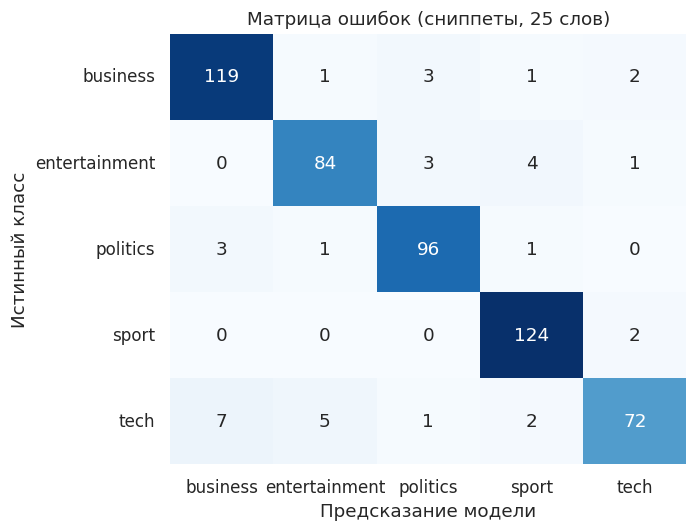

In [14]:
cm = confusion_matrix(y_test, pred, labels=classes)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel("Предсказание модели")
ax.set_ylabel("Истинный класс")
ax.set_title("Матрица ошибок (сниппеты, 25 слов)")
plt.tight_layout()
plt.show()

Диагональ матрицы - правильные предсказания, все ячейки вне диагонали - ошибки. По строке `tech` действительно видно, что этот класс чаще других путается с соседними категориями.

Но на одной картинке легко ошибиться в интерпретации. Поэтому найдем самые частые пары ошибок программно - так мы точно увидим, какие классы модель путает между собой и насколько часто это происходит.


In [15]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(cm_off.ravel())[::-1], cm_off.shape))[0]

print("Самые частые путаницы (истинный - предсказанный):")
for i, j in pairs[:6]:
    if cm[i, j] > 0:
        print(f"{classes[i]} - {classes[j]}: {cm[i, j]}")

Самые частые путаницы (истинный - предсказанный):
tech - business: 7
tech - entertainment: 5
entertainment - sport: 4
politics - business: 3
business - politics: 3
entertainment - politics: 3


**Вопрос на подумать**

Почему `tech` чаще путается с `business` и `entertainment`, а не, например, со `sport`? Сформулируйте гипотезу до того, как начнем читать тексты.

**Возможное объяснение**

Возможное объяснение - пересечение лексики и тематики. Технологические новости часто рассказывают о компаниях, продуктах и рынках - здесь появляется лексика, характерная для `business`. Кроме того, часть `tech`-новостей связана с играми, кино, музыкой и гаджетами для развлечений, что создает пересечение с `entertainment`.

Со `sport` пересечение обычно слабее: спортивные новости чаще содержат специфическую лексику, которая редко встречается в технологических текстах. Поэтому путаница `tech - sport` должна быть значительно меньше.

### 4.2. Читаем конкретные ошибки

Это один из самых важных шагов анализа ошибок. Метрики показывают масштаб проблемы, но не ее причины. Чтобы понять, почему модель ошибается и что можно улучшить, нужно посмотреть на конкретные примеры.

Поэтому сейчас отложим агрегированные метрики и прочитаем несколько ошибок модели глазами. Часто уже по первым примерам становится понятно, что именно не хватает модели: контекста, нужных признаков или самой информации во входном тексте.

In [16]:
errors = eval_df[~eval_df["correct"]].copy()
show = errors[errors["label"].isin(["tech", "business", "politics"])].head(8)

for _, r in show.iterrows():
    print(f"[истина: {r['label']} - модель: {r['pred']} | увер.={r['confidence']:.2f}]")
    print(r["snippet"][:120], "\n")

[истина: tech - модель: entertainment | увер.=0.37]
The Force is strong in Battlefront The warm reception that has greeted Star Wars: Battlefront is a reflection not of any 

[истина: tech - модель: business | увер.=0.51]
Lasers help bridge network gaps An Indian telecommunications firm has turned to lasers to help it overcome the problems  

[истина: politics - модель: entertainment | увер.=0.35]
'Few ready' for information act Thousands of public bodies are ill-prepared for the Freedom of Information Act, due to c 

[истина: tech - модель: business | увер.=0.57]
Hitachi unveils 'fastest robot' Japanese electronics firm Hitachi has unveiled its first humanoid robot, called Emiew, t 

[истина: tech - модель: entertainment | увер.=0.47]
US top of supercomputing charts The US has pushed Japan off the top of the supercomputing chart with IBM's prototype Blu 

[истина: business - модель: politics | увер.=0.59]
EU ministers to mull jet fuel tax European Union finance ministers are meeting o

Прочитайте эти примеры внимательно - они хорошо показывают, почему одной метрики недостаточно:

- *"...Star Wars: Battlefront..."* - статья про видеоигру. Формально она относится к `tech`, но по содержанию легко воспринимается как `entertainment`. Это действительно неоднозначный случай: два человека-разметчика вполне могли бы выбрать разные классы.
- *"...telecommunications firm... lasers..."*, *"...electronics firm Hitachi... robot..."* - истинный класс `tech`, но слово firm характерно для `business` и может потянуть предсказание в эту сторону. Это пример пересечения лексики между классами.
- *"...finance ministers... jet fuel tax..."* - текст относится к `business`, но слова "ministers" и "tax" создают сильную ассоциацию с `politics`.

**Важно**

Ошибки могут возникать по разным причинам, и способы их исправления тоже будут разными:

1. Неоднозначность примера - например, игра может относиться и к `tech`, и к `entertainment`. Это может быть ограничением самой постановки задачи. Иногда полезнее уточнить правила разметки, чем пытаться любой ценой "научить" модель различать искусственно размытые классы.

2. Пересечение лексики - например, слово *firm* встречается в новостях разных тематик. Здесь могут помочь дополнительные признаки, больше контекста, n-граммы или более содержательные представления текста.

3. Ошибки или шум в разметке - иногда то, что выглядит как ошибка модели, на самом деле указывает на проблему в данных.

Метрика может сказать: "recall для `tech` равен 0.83". Но только анализ конкретных ошибок помогает понять, что стоит за этим числом и куда направить дальнейшие улучшения.


### 4.3. Заглядываем в модель: что она выучила

Логистическая регрессия интерпретируема: для каждого признака знак и величина веса показывают, как этот признак влияет на решение модели в пользу конкретного класса.

Посмотрим на слова с наибольшими положительными весами для каждого класса. Они покажут, какая лексика сильнее всего "тянет" модель к `business`, `entertainment`, `politics`, `sport` и `tech`.

Это позволит сопоставить то, что модель выучила, с теми ошибками, которые мы только что увидели: например, проверить, действительно ли `firm` имеет большой вес для `business` и поэтому может сбивать технологические новости.

In [17]:
feature_names = np.array(vec.get_feature_names_out())

print("Топ-10 слов-индикаторов каждого класса:\n")
for ci, c in enumerate(classes):
    top = feature_names[clf.coef_[ci].argsort()[::-1][:10]]
    print(f"{c:}: {', '.join(top)}")

Топ-10 слов-индикаторов каждого класса:

business: firm, shares, economy, prices, economic, its, bank, us, india, oil
entertainment: film, music, star, singer, tv, band, awards, show, box, oscars
politics: labour, blair, brown, election, plans, party, government, mps, minister, tory
sport: cup, chelsea, coach, manager, rugby, athletics, tennis, ireland, england, championships
tech: net, games, mobile, computer, apple, digital, web, broadband, software, sony


Веса подтверждают гипотезу: среди самых сильных признаков для `business` - `firm, shares, bank`, а для `tech` - `net, games, apple, mobile`. Теперь мы можем увидеть механизм конкретной ошибки: в тексте *"electronics firm unveils robot"* слово *firm* дает сильный сигнал в пользу `business`, хотя весь текст относится к `tech`.

**Вопрос на подумать**

Как превратить это наблюдение в гипотезу об улучшении? Придумайте 2-3 идеи и объясните, какую проблему каждая из них должна решить.

**Возможные идеи**
- Добавить n-граммы: сочетания вроде *"electronics firm"* или *"tech firm"* могут нести больше информации, чем отдельное слово *firm*.
- Дать модели больше контекста: использовать не только первые 25 слов, но все предложение или более длинный фрагмент. Возможно, дополнительные слова помогут правильно определить тему.
- Перейти к эмбеддингам или контекстным моделям: такие представления могут лучше учитывать окружение слова и различать разные значения и контексты его употребления.
- Изменить саму постановку задачи: если `business` и `tech` слишком сильно пересекаются и бизнес-задача не требует их различать, можно рассмотреть объединение классов.



### 4.4. Работа с уверенностью модели

`predict_proba` дает оценку вероятности для каждого класса. Поэтому полезно анализировать не только сам факт ошибки, но и то, как распределены вероятности между классами.

Две ошибки могут выглядеть одинаково с точки зрения accuracy, но сильно отличаться по смыслу: модель могла присвоить неверному предсказанному классу вероятность, близкую к `0.51`, или, наоборот, близкую к `0.99`. Насколько эти случаи разные, зависит от того, как остальная вероятность распределена между другими классами.

В бинарной классификации, если вероятность предсказанного класса равна `0.51`, второй класс автоматически получает `0.49`, и решение действительно находится близко к границе. В многоклассовой задаче это не так: оставшиеся `0.49` могут быть размазаны по многим классам, и тогда `0.51` - это очень уверенное решение. Поэтому для многоклассовой задачи вместо абсолютного порога вроде `0.5` используют пару характеристик:

```text
confidence = p(top-1)
margin = p(top-1) - p(top-2)
```

`confidence` - вероятность предсказанного класса. `margin` - отрыв от ближайшего конкурента: маленький `margin` означает, что модель почти одинаково оценивает два ведущих класса, то есть решение действительно пограничное.

Заметим также, что `predict_proba` - это в первую очередь **численная оценка уверенности модели**. Называть ее вероятностью правильности можно только после проверки калибровки модели, поэтому ниже мы интерпретируем значения осторожно, как относительную меру уверенности.


In [18]:
confident_errors = errors.sort_values(
    ["top1_proba", "margin"], ascending=[False, False]
).head(4)
print("Самые 'уверенные' ошибки (максимальные top1 и margin):\n")
for _, r in confident_errors.iterrows():
    print(f"[{r['label']} - {r['pred']} | top1={r['top1_proba']:.2f}, margin={r['margin']:.2f}]  {r['snippet'][:110]}\n")

Самые 'уверенные' ошибки (максимальные top1 и margin):

[tech - sport | top1=0.95, margin=0.92]  Piero gives rugby perspective BBC Sport unveils its new analysis tool Piero at the Wales v England rugby union

[tech - entertainment | top1=0.83, margin=0.69]  Hollywood to sue net film pirates The US movie industry has launched legal action to sue people who facilitate

[tech - politics | top1=0.78, margin=0.68]  Online commons to spark debate Online communities set up by the UK government could encourage public debate an

[business - politics | top1=0.67, margin=0.56]  G7 backs Africa debt relief plan G7 finance ministers have backed plans to write off up to 100% of the debts o



In [19]:
borderline_errors = errors.sort_values(
    ["margin", "top1_proba"], ascending=[True, True]
).head(4)
print("Самые 'пограничные' ошибки (минимальный margin):\n")
for _, r in borderline_errors.iterrows():
    print(f"[{r['label']} - {r['pred']} | top1={r['top1_proba']:.2f}, margin={r['margin']:.2f}]  {r['snippet'][:110]}\n")

Самые 'пограничные' ошибки (минимальный margin):

[tech - business | top1=0.32, margin=0.01]  Supercomputer breaks speed record The US is poised to push Japan off the top of the supercomputing chart with 

[tech - business | top1=0.34, margin=0.01]  Fast lifts rise into record books Two high-speed lifts at the world's tallest building have been officially re

[entertainment - tech | top1=0.32, margin=0.01]  Glastonbury fans to get ID cards Fans who buy tickets for this year's Glastonbury festival will be issued with

[politics - business | top1=0.31, margin=0.03]  UK's 'useless' quangos under fire The UK has 529 quangos financed with billions of pounds of taxpayers' cash -



In [20]:
# Нормированная энтропия распределения вероятностей: общая неопределенность
safe_proba = np.clip(proba, 1e-12, 1.0)
entropy = -(safe_proba * np.log(safe_proba)).sum(axis=1)
eval_df["normalized_entropy"] = entropy / np.log(proba.shape[1])

errors = eval_df[~eval_df["correct"]].copy()
ambiguous_errors = errors.sort_values("normalized_entropy", ascending=False).head(4)
print("Ошибки с максимальной неопределенностью (по нормированной энтропии):\n")
for _, r in ambiguous_errors.iterrows():
    print(f"[{r['label']} - {r['pred']} | top1={r['top1_proba']:.2f}, margin={r['margin']:.2f}, H={r['normalized_entropy']:.2f}]  {r['snippet'][:110]}\n")

Ошибки с максимальной неопределенностью (по нормированной энтропии):

[politics - business | top1=0.27, margin=0.06, H=0.98]  Probe launched on Ken Nazi jibe An investigation by the Standards Board is under way following allegations tha

[tech - sport | top1=0.29, margin=0.04, H=0.95]  Kenyan school turns to handhelds At the Mbita Point primary school in western Kenya students click away at a h

[politics - business | top1=0.34, margin=0.08, H=0.94]  Voters 'reject EU by two to one' British voters would reject the European constitution by two to one, accordin

[politics - entertainment | top1=0.35, margin=0.09, H=0.94]  'Few ready' for information act Thousands of public bodies are ill-prepared for the Freedom of Information Act



In [21]:
# Связь уверенности и правильности: точность в интервалах уверенности
bins = pd.cut(eval_df["confidence"], [0, 0.5, 0.7, 0.9, 1.01], labels=["0.0–0.5", "0.5–0.7", "0.7–0.9", "0.9–1.0"])
tab = eval_df.groupby(bins)["correct"].agg(n="size", accuracy="mean").round(3)
print(tab)

              n  accuracy
confidence               
0.0–0.5      86     0.733
0.5–0.7     100     0.890
0.7–0.9     211     0.991
0.9–1.0     135     0.993


Видна почти монотонная зависимость: чем увереннее модель, тем чаще она оказывается права. В бине `0.9-1.0` точность около `0.99`, а при низкой уверенности она заметно ниже.

Это открывает практический прием - **abstention (воздержание от предсказания)**: тексты с низкой уверенностью не классифицировать автоматически, а отправлять на ручную проверку.

**Но осторожно.** Ранее мы видели ошибку `tech -> sport` с уверенностью 0.95 - это была новость об аналитическом инструменте BBC для регби, в которой оказалось много спортивной лексики. То есть высокая уверенность **не гарантирует правильность**: модель может быть уверенно неправа.

Поэтому порог уверенности может снизить риск автоматических ошибок, но не устранить его полностью. Особенно важно помнить об этом для случаев, где цена ошибки высока.


### 4.5. Проверяем гипотезы об улучшении

Из анализа ошибок появилась гипотеза: добавим биграммы, чтобы учитывать словосочетания и контекст соседних слов. Звучит разумно, но в ML одной интуиции недостаточно - даже хорошая идея может не дать улучшения.

Поэтому следующий шаг - проверить гипотезу экспериментально: обучить модель с биграммами и сравнить ее качество с бейзлайном на тех же данных и по тем же метрикам.


In [22]:
def evaluate(ngram_range, n_words=None, label="", min_df=3):
    tr = train_df["text"].apply(make_snippet, n_words=n_words) if n_words else train_df["snippet"]
    te = test_df["text"].apply(make_snippet, n_words=n_words) if n_words else test_df["snippet"]
    v = TfidfVectorizer(min_df=min_df, max_df=0.6, sublinear_tf=True, ngram_range=ngram_range)
    Xt = v.fit_transform(tr)
    Xv = v.transform(te)
    m = LogisticRegression(C=5, max_iter=2000).fit(Xt, y_train)
    p = m.predict(Xv)
    print(f"{label} acc={accuracy_score(y_test, p):.3f}  macro-F1={f1_score(y_test, p, average='macro'):.3f}")

evaluate((1, 1), label="бейзлайн (сниппет 25 слов, униграммы)")
evaluate((1, 2), label="+ биграммы")

бейзлайн (сниппет 25 слов, униграммы) acc=0.930  macro-F1=0.926
+ биграммы acc=0.923  macro-F1=0.919


In [23]:
# Размер словаря и разреженность матриц признаков для разных ngram_range
for ngr in [(1, 1), (1, 2), (2, 2)]:
    v = TfidfVectorizer(min_df=3, max_df=0.6, sublinear_tf=True, ngram_range=ngr)
    X = v.fit_transform(train_df["snippet"])
    sparsity = 1 - X.nnz / (X.shape[0] * X.shape[1])
    print(f"ngram_range={ngr}: признаков={X.shape[1]}, разреженность={sparsity:.4f}")

ngram_range=(1, 1): признаков=2179, разреженность=0.9922
ngram_range=(1, 2): признаков=3747, разреженность=0.9940
ngram_range=(2, 2): признаков=1568, разреженность=0.9964


In [24]:
# Документная и терм-частота биграмм до фильтрации min_df
raw = CountVectorizer(ngram_range=(2, 2), min_df=1)
X_raw = raw.fit_transform(train_df["snippet"])
bigrams = raw.get_feature_names_out()

bigram_freq = pd.DataFrame({
    "bigram": bigrams,
    "term_frequency": X_raw.sum(axis=0).A1,
    "document_frequency": (X_raw > 0).sum(axis=0).A1,
})

removed = (bigram_freq["document_frequency"] < 3).sum()
total_bigrams = len(bigram_freq)
print(f"Всего уникальных биграмм: {total_bigrams}")
print(f"Менее чем в 3 документах (удаляются при min_df=3): {removed} ({removed / total_bigrams:.1%})")
print("\nСамые редкие биграммы по документной частоте:")
display(bigram_freq.sort_values(["document_frequency", "term_frequency"]).head(10))

filt = CountVectorizer(ngram_range=(2, 2), min_df=3, max_df=0.6)
X_filt = filt.fit_transform(train_df["snippet"])
df_filt = (X_filt > 0).sum(axis=0).A1
print(f"\nОсталось биграмм после min_df=3: {X_filt.shape[1]}")
print(f"Минимальная document frequency среди оставшихся: {df_filt.min()}")
assert df_filt.min() >= 3

Всего уникальных биграмм: 27046
Менее чем в 3 документах (удаляются при min_df=3): 25478 (94.2%)

Самые редкие биграммы по документной частоте:


,bigram,term_frequency,document_frequency
0,00 59,1,1
1,000 390,1,1
2,000 and,1,1
3,000 as,1,1
5,000 bond,1,1
6,000 business,1,1
7,000 civil,1,1
8,000 fine,1,1
9,000 following,1,1
10,000 four,1,1



Осталось биграмм после min_df=3: 1568
Минимальная document frequency среди оставшихся: 3


In [25]:
# Влияние порога отсечения редких признаков min_df на качество
for min_df in [1, 2, 3, 5, 10]:
    evaluate((1, 2), label=f"биграммы, min_df={min_df}", min_df=min_df)

биграммы, min_df=1 acc=0.919  macro-F1=0.917
биграммы, min_df=2 acc=0.927  macro-F1=0.924
биграммы, min_df=3 acc=0.923  macro-F1=0.919
биграммы, min_df=5 acc=0.910  macro-F1=0.906
биграммы, min_df=10 acc=0.870  macro-F1=0.866


Биграммы в этом эксперименте не дали улучшения: на этом разбиении качество оказалось на уровне бейзлайна или немного ниже. Разберемся, что происходит с биграммами в данных, а не в интуиции.

**Важное уточнение про `min_df`.** В `TfidfVectorizer` параметр `min_df` задает минимальную **документную частоту**: признак попадает в словарь, только если он встречается в `min_df` документах обучающей выборки. Это число документов, а не суммарное число появлений во всем корпусе.

Диагностика выше показывает:
- при `min_df=3` более 94% биграмм встречаются менее чем в трех документах и удаляются из словаря;
- даже после фильтрации добавление биграмм заметно увеличивает словарь и разреженность матриц признаков;
- изменение `min_df` меняет качество, но ни один вариант не дал улучшения на этом разбиении.

Это наблюдение конкретного эксперимента на одном разбиении, а не доказанная причина. Чтобы говорить точнее, нужны несколько разбиений или кросс-валидация.

Проверим следующую гипотезу: проблема не столько в модели и признаках, сколько в **нехватке контекста**. Возможно, первых 25 слов просто недостаточно для надежной классификации. Дадим модели больше текста и посмотрим, изменится ли качество.


In [26]:
evaluate((1, 1), n_words=25, label="25 слов")
evaluate((1, 1), n_words=40, label="40 слов")
evaluate((1, 1), n_words=100, label="100 слов")

25 слов acc=0.930  macro-F1=0.926
40 слов acc=0.951  macro-F1=0.949
100 слов acc=0.949  macro-F1=0.947


Здесь виден реальный выигрыш: переход от 25 к 40 словам дает прирост качества, а при переходе к 100 словам наступает насыщение - дополнительный контекст уже почти не улучшает результат. Это хороший пример **убывающей отдачи от количества информации**: контекст помогает, но только до определенного предела.

**Главный вывод здесь:**

Главным рычагом улучшения оказался входной контекст, а не усложнение модели. В ML легко сразу потянуться к более сложному алгоритму, но часто более дешевый выигрыш находится в данных и признаках.

Поэтому разумный порядок действий такой: **простая модель - честная оценка - анализ ошибок - гипотеза - эксперимент**. И только когда мы понимаем, где находится ограничение и простые изменения перестают помогать, имеет смысл переходить к более сложной модели.


## Итоги

* **Бейзлайн собирается за минуты, а основная работа начинается с анализа ошибок.** Пока вы не посмотрели на конкретные промахи, вы не знаете, почему модель ошибается и, следовательно, что именно стоит улучшать.

* **Одна accuracy может вводить в заблуждение на несбалансированных данных.** Смотрите на `precision` и `recall` для каждого класса, `macro-F1` и сравнивайте результат с `DummyClassifier`. Метрику нужно выбирать с учетом цены ошибок: если критично не пропустить объекты класса - важнее `recall`, если важнее избегать ложных срабатываний - `precision`. При необходимости можно использовать `F_beta`.

* **Разные инструменты анализа отвечают на разные вопросы:** матрица ошибок показывает, где возникает путаница, конкретные тексты помогают понять, почему она возникает, а веса модели показывают, какие признаки влияют на решение. Вместе они дают гораздо более полную картину.

* **Уверенность модели связана с вероятностью правильного ответа, но не гарантирует его.** Порог по вероятности и abstention могут снизить риск автоматических ошибок, но сценарий "уверенно неправа" остается возможным.

* **Гипотезы об улучшении нужно проверять экспериментально.** Правдоподобная идея, например, добавление биграмм, может не дать результата. В нашем случае заметный выигрыш принесло увеличение контекста, а не усложнение модели.

**Главный принцип:** не начинайте с вопроса "какую более сложную модель попробовать?". Сначала спросите: "где модель ошибается, почему она ошибается и что мы можем проверить?".


## Вопросы для рефлексии

- **Появился новый класс**, например `science`, которого не было в обучении. Что предскажет наша модель для таких текстов и как это обнаружить в проде? (Подсказка: модель все равно выберет один из известных классов, поскольку не умеет сама сообщать "это новый класс". Помочь могут мониторинг доли низкоуверенных предсказаний и распределения предсказанных классов.)

- **Задача стала multi-label** - у одной статьи теперь может быть несколько тегов. Что придется изменить в модели и функции потерь?

- **Изменение в данных (drift):** появились новости про технологию, которой не было в train. Как это может повлиять на качество и как заметить проблему без разметки? (Подсказка: следить за долей низкоуверенных предсказаний и изменением распределения слов и признаков.)

- **Нужна максимальная интерпретируемость для регулятора.** Что выберете - логистическую регрессию или нейросеть? Какие аргументы приведете в пользу своего выбора? Подумайте не только о качестве, но и о возможности объяснить решение модели.

### Связь с ДЗ

В домашнем задании "Классификация новостей по темам" вы будете сравнивать методы векторизации на похожей задаче. Перенесите туда весь сегодняшний чек-лист:
- проверьте датасет на дубликаты;
- зафиксируйте честное разбиение train/test;
- не ограничивайтесь одной accuracy;
- смотрите на качество по каждому классу;
- обязательно прочитайте конкретные ошибки и объясните, почему модель их совершает;
- формулируйте гипотезы об улучшении и проверяйте их экспериментально, а не только на уровне интуиции.
